# Spread Locator : A Statistical Distribution Analysis Model

## Part A : Theoratical Foundation

##### 1. What is Statistical Distributions ?
###### -> A Statistical Distribution describes how the values of a random variable are spread (or distributed) across possible outcomes.
######    It tells us:
######    - What values a variable can take.
######    - How often (probability or frequency) those values occur.

##### 2. What is Q-Q Plot and why is it used ?
###### -> A Q-Q Plot is a graphical tool to check whether a dataset follows a particular theoretical distribution (often the Normal Distribution).

######    Q-Q Plot mainly used to :

######    a. Check Normality of Data 
######    - Determines whether data follows a normal distribution.
######    - Very important before applying tests like t-test, ANOVA, Regression etc.

######    b. Detect Outliers

######    c. Compare Two Distributions
######    - Helps identify whether two datasets have similar distributions.


##### 3. What is the difference between Discrete and Normal Distribution ?
###### -> Discrete Distribution	-------------------------------------------------> Continuous Distribution
######    - Deals with countable values.------------------------------------------ Deals with measurable values.
######    - Random variable takes specific distinct values.----------------------- Random variable can take any value within an interval.
######    - Probability is calculated using PMF (Probability Mass Function).------ Probability is calculated using PDF (Probability Density Function).
######    - Gaps exist between possible values.----------------------------------- No gaps between values.
######    - Examples: Number of students, number of heads in coin tosses.--------- Examples: Height, weight, temperature, time.
######    - Common distributions: Bernoulli, Binomial, Poisson.------------------- Common distributions: Normal, Exponential, Uniform.

##### 4. What is Bernouli Distribution ?
###### -> A Bernouli Distribution is the simplest probability distribution.
###### It describes a random experiment with only two possible outcomes:
###### - Success (1) with probability p
###### - Failure with (0) with probability 1-p

##### 5. What is Binomial Distribution ?
###### -> The Binomial Distribution is an extension of Bernouli.
###### It models the probability of getting k success in n independent Bernouli trials.

##### 6. Explain Log-Normal Distribution.
##### -> Definition :
###### A Log-Normal Distribution is a probability distribution in which the logarithm of the variable is normally distributed.

###### In simple words:

###### If X follows a Log-Normal Distribution,
###### then ln(X) follows a Normal Distribution.

##### Mathematical Form :
###### If,
#### Y=ln(X)
###### and Y is normally distributed, then X is said to be Log-Normally Distributed.

##### Characteristics
###### - Values are always positive (X>0)
###### - Distribution is right-skewed (long tail on the right)
###### - Mean > Median > Mode
###### - Common in real-world growth processes

##### Why is it Used?

###### -> It is used when:

######    - Data cannot be negative.
######    - Growth occurs multiplicatively rather than additively.
######    - Data is highly right-skewed.

######    - In Data Science, it helps model:

######    - Financial returns
######    - Business revenues
######    - Web traffic
######    - Biological measurements

##### 7. Explain Power-Law Distribution.
##### -> Definition

###### A Power-Law Distribution is a probability distribution in which small values occur very frequently, while extremely large values occur rarely but have a significant impact.

##### Mathematically:

##### P(X=x)∝x
##### −α

##### where:

###### P(X=x) = probability of value x
###### α = power-law exponent (a positive constant)

##### Key Characteristics

###### - Many small events and very few large events
###### -  Has a heavy tail (large values are more likely than in a normal distribution)
###### -  Not symmetric like a normal distribution
###### -  Often follows the 80-20 rule (Pareto Principle)

##### Examples
###### - Wealth Distribution :
######   Most people have moderate wealth.
######   A few people own enormous wealth.

##### Importance in Data Science
###### - Detects rare but important events.
###### - Used in network analysis and social media analytics.
###### - Helps model real-world phenomena where extreme values matter.

##### 8. What is Box-Cox Transform ? 
###### -> Box-Cox Transform is a mathematical transformation used to make skewed data more normally distributed and stabilize variance.

###### It helps improve the performance of many statistical and machine learning models that assume normally distributed data.

##### Why is it Used?

###### - Reduces skewness in data
###### - Makes data closer to a normal distribution
###### - Stabilizes variance
###### - Improves accuracy of regression and statistical models

##### 9. Explain Poisson Distribution with example.
###### -> The Poisson Distribution models the probability of a given numbers of events happening in a fixed interval of time, space or area, if:
###### - Events occur independently
###### - Events occur at a constant average rate (λ)
###### - Two or more events do not happen simultaneously
###### It's a Discrete Distribution.

##### Real-Life Examples :
###### - Number of emails received in an hour.
###### - Number of printing error per 100 pages.
###### - Number of cars passing through a toll booth per minute.

##### 10. What is Z-score Probability ?
###### -> Z-Score Probability is the probability associated with a particular Z-score, which tells us how likely it is for a value to occur in a normal distribution.

###### A Z-score indicates how many standard deviations a value is above or below the mean.

##### Interpretation
###### - z = 0 → Value is exactly at the mean.
###### - z > 0 → Value is above the mean.
###### - z < 0 → Value is below the mean.

###### - The Z-score is then used with a Z-table to find the probability of obtaining that value or a value less than it.

##### 11. Differentiate Probability Density Function (PDF) and Cumulative Distribution Function (CDF). 
##### -> PDF (Probability Density Function)	
###### - Describes the density of probability at a specific value.	
###### - Used for continuous random variables.	
###### - Gives the relative likelihood of values.	
###### - Probability at a single point is 0.	
###### - The area under the PDF curve between two points gives probability.	
###### - PDF curve may increase or decrease. 
####   - f(x)

##### -> CDF (Cumulative Distribution Function)
###### - Describes the cumulative probability up to a specific value.
###### - Used for both discrete and continuous random variables.
###### - Gives the probability that X≤x.
###### - Probability accumulates from the left up to x.
###### - The CDF value itself represents probability.
###### - CDF is always non-decreasing and ranges from 0 to 1. 
####   - F(x)=P(X≤x)

## Part B : Data Analysis and Testing Tasks  

##### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, norm

##### Load Dataset

In [6]:
df = pd.read_csv("spread_locator_dataset.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

##### Task 1 : Fit Bernoulli and Binomial Distributions

In [19]:
#--------- Bernoulli ------------

p = (df['transaction_status'] == 'Success').mean()

success = bernoulli.pmf(1, p)
failure = bernoulli.pmf(0, p)

print(f"Bernoulli PMF (Success=1) : {success:.4f}")
print(f"Bernoulli PMF (Failure=0) : {failure:.4f}")


#--------- Binomial ------------

p = (df['transaction_status'] == 'Success').mean()
n = int(df['transaction_count'].max())   
k = int(df['transaction_count'].mode()[0])  

binomial = binom.pmf(k, n, p)
print()
print(f"Binomial PMF (k={k}, n={n}, p={p:}) : {binomial:.4f}")


Bernoulli PMF (Success=1) : 0.4455
Bernoulli PMF (Failure=0) : 0.5545

Binomial PMF (k=2, n=9, p=0.44545454545454544) : 0.1152


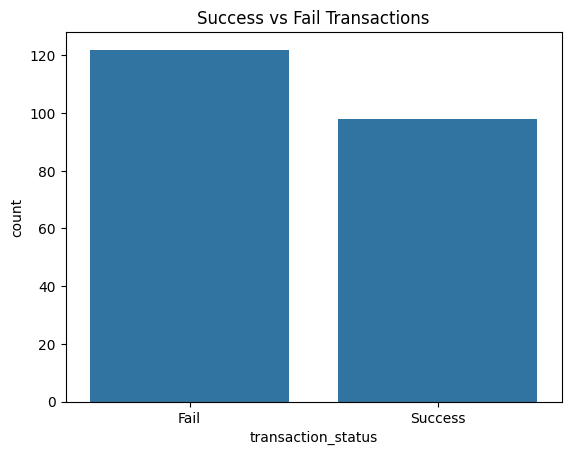

In [18]:
#---------- Bernoulli Visual ----------
sns.countplot(x='transaction_status', data=df)
plt.title("Success vs Fail Transactions")
plt.show()

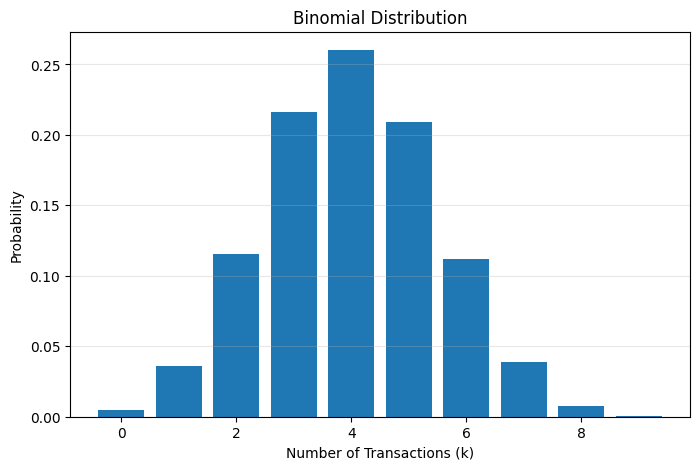

In [20]:
x = np.arange(0, n+1)

# Binomial probabilities
y = binom.pmf(x, n, p)

# Plot
plt.figure(figsize=(8,5))
plt.bar(x, y)

plt.title("Binomial Distribution")
plt.xlabel("Number of Transactions (k)")
plt.ylabel("Probability")
plt.grid(axis='y', alpha=0.3)

plt.show()

##### Task 2 : Fit Poisson Distribution

In [22]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
trans_p_day = df.groupby('transaction_date').size()

l = round(trans_p_day.mean())  
k   = int(trans_p_day.mode()[0]) 

poisson_dis = poisson.pmf(k, l)

print(f"\nPoisson PMF P(X={k}) : {poisson_dis:.4f}")
print(f"Probability of exactly {k} transactions in a day = {poisson_dis*100:.2f}%")


Poisson PMF P(X=6) : 0.1490
Probability of exactly 6 transactions in a day = 14.90%


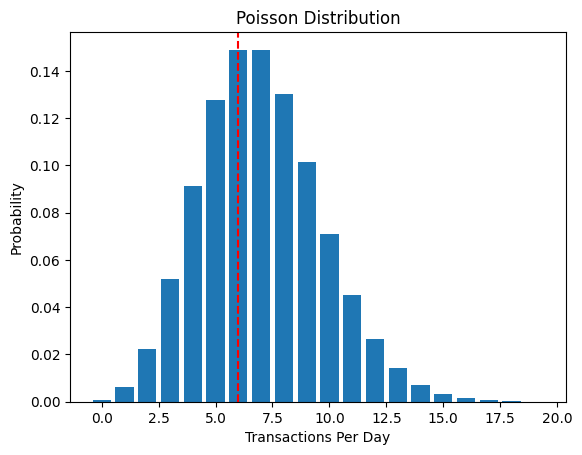

In [23]:
# --------------- Poisson Visual ---------------
x = np.arange(0,20)
y = poisson.pmf(x,l)

plt.bar(x,y)

plt.axvline(k,color='red',linestyle='--')
plt.title("Poisson Distribution")
plt.xlabel("Transactions Per Day")
plt.ylabel("Probability")
plt.show()

##### Task 3 : Model transactions amounts using Log-Normal & Power Law Distribution

In [26]:
ammount = df['transaction_amount'].dropna()

mean = np.mean(np.log(ammount))
std = np.std(np.log(ammount))

print(f"Mean = {mean}")
print(f"Standars Deviation = {std}")

Mean = 8.000738129859133
Standars Deviation = 0.4749178350151927


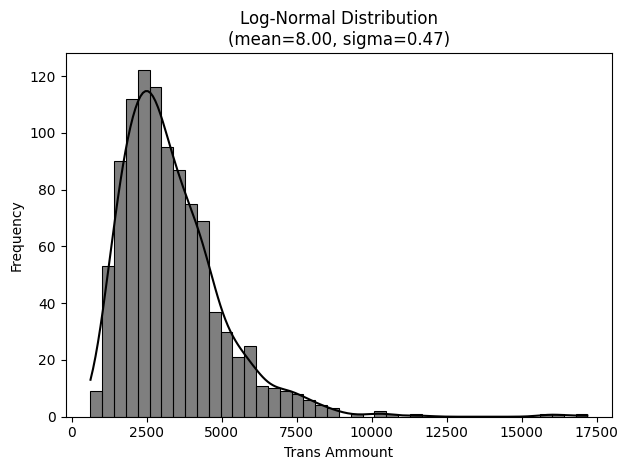

In [27]:
# -------------- Visual --------------
lognorm = np.random.lognormal(mean=mean, sigma=std, size=1000)

sns.histplot(lognorm, kde=True, color='black')
plt.title(f"Log-Normal Distribution\n(mean={mean:.2f}, sigma={std:.2f})")
plt.xlabel("Trans Ammount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##### Task 4 : Generate & Interpret Q-Q Plot to test normality

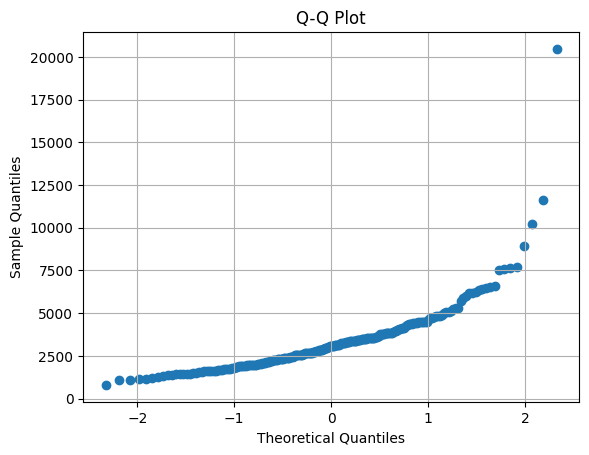

In [29]:
sample_data = np.sort(ammount)

theoretical_quantiles = norm.ppf(
    np.linspace(0.01, 0.99, len(sample_data))
)


# Plot
plt.scatter(theoretical_quantiles, sample_data)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("Q-Q Plot")

plt.grid(True)
plt.show()

##### Task 5 : Apply Box-Cox to stabilize variance 

Lambda = -0.18


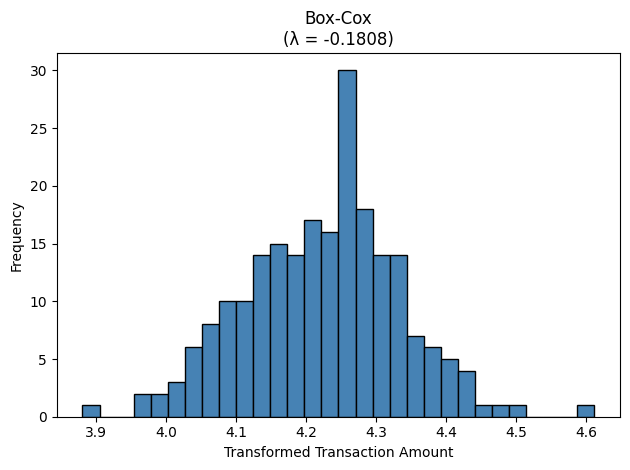

In [32]:
from scipy.stats import boxcox

boxcox_data,lam = boxcox(ammount)

print("Lambda =", round(lam,2))


# -------- Plot --------
plt.hist(boxcox_data, bins=30, color='steelblue', edgecolor='black')
plt.title(f"Box-Cox\n(λ = {lam:.4f})")
plt.xlabel("Transformed Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##### task 6 : Calculate Z-Scores for transaction amount and compute probability of transactions exceeding Rs,5,000

In [33]:
from scipy.stats import zscore

df['Z_score'] = zscore(ammount)

print(df[['transaction_amount','Z_score']].head())

   transaction_amount   Z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179


##### Probability above 5000

In [34]:
mean = ammount.mean()
std = ammount.std()

z = (5000-mean)/std

prob = 1-norm.cdf(z)

print(f"Probability Amount > ₹5000 = {prob:.4f}")
print(f"Percentage (%) = {prob*100:.2f}%")

Probability Amount > ₹5000 = 0.2052
Percentage (%) = 20.52%


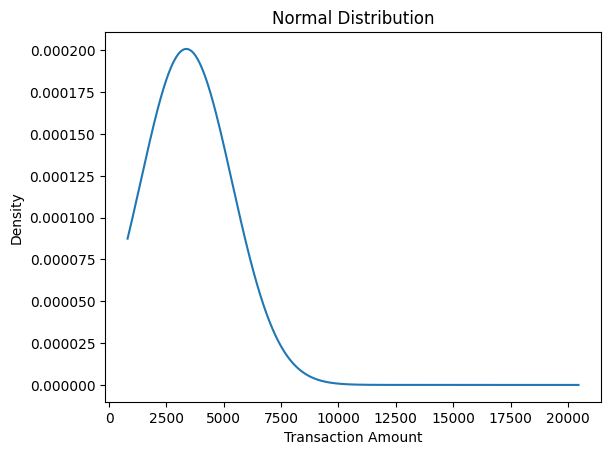

In [35]:
x = np.linspace(ammount.min(), ammount.max(), 1000)
pdf = norm.pdf(x, mean, std)

plt.plot(x, pdf)
plt.title("Normal Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.show()

##### Task 7 : Plot and interpret PDF and CDF for transaction amounts

##### PDF

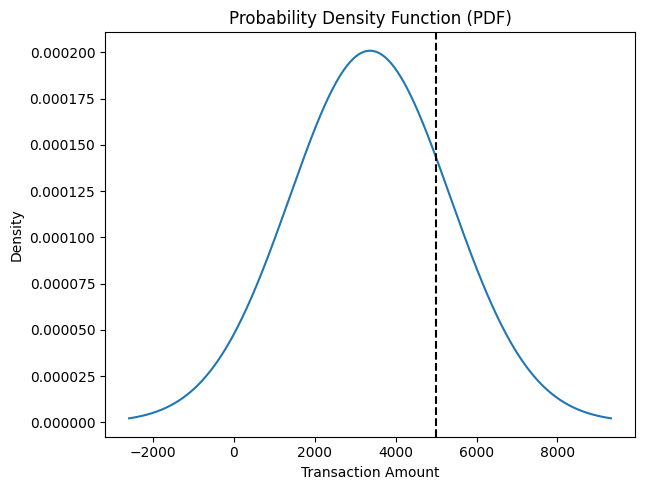

In [48]:
mu    = ammount.mean()
std = ammount.std()
x     = 5000

x_values   = np.linspace(mu - 3*std, mu + 3*std, 500)
pdf_values = norm.pdf(x_values, mu, std)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_values, pdf_values)
plt.axvline(x, color="black", linestyle="--")
plt.title("Probability Density Function (PDF)")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

##### CDF

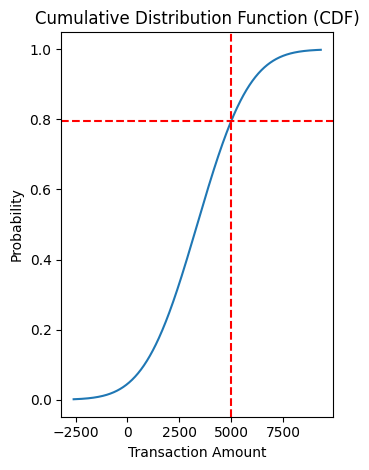

In [51]:
cdf = norm.cdf(5000, mean, std)
mu    = ammount.mean()
std = ammount.std()
x     = 5000

xval   = np.linspace(mu - 3*std, mu + 3*std, 500)
cdfval = norm.cdf(x_values, mu, std)

plt.subplot(1, 2, 2)
plt.plot(xval, cdfval)
plt.axvline(x, color="red", linestyle="--")
plt.axhline(cdf, color="red", linestyle="--")
plt.title("Cumulative Distribution Function (CDF)")
plt.xlabel("Transaction Amount")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

##### Task 8 : Conclude which distribution best fits for the dataset and justify insights for decision-making

Skewness = 3.76
P-value = 0.0
Data is NOT NORMAL


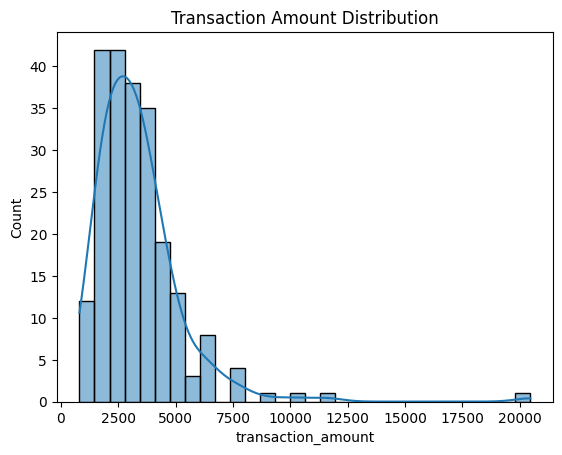


Best Fit Distribution : Log-Normal Distribution
Reason : Transaction amounts are positive and highly right-skewed.


In [53]:
# ----- Compare Skewness -----
print("Skewness =", round(ammount.skew(), 2))

# ----- Check Normality -----
from scipy.stats import shapiro

stat, p_value = shapiro(ammount)

print("P-value =", round(p_value, 4))

print("Data is NORMAL" if p_value > 0.05 else "Data is NOT NORMAL")

# ----- Visual Check -----
sns.histplot(ammount, kde=True)

plt.title("Transaction Amount Distribution")
plt.show()

# ----- Final Conclusion -----
if ammount.skew() > 1:
    print("\nBest Fit Distribution : Log-Normal Distribution")
    print("Reason : Transaction amounts are positive and highly right-skewed.")
else:
    print("\nBest Fit Distribution : Normal Distribution")
    print("Reason : Data is approximately symmetric.")